## Langkah 1 — Import library

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


## Langkah 2 — Muatkan dan semak dataset MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 32.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.12MB/s]


Training data: 60000
Testing data: 10000
Image shape: torch.Size([1, 28, 28])
Actual label: 7


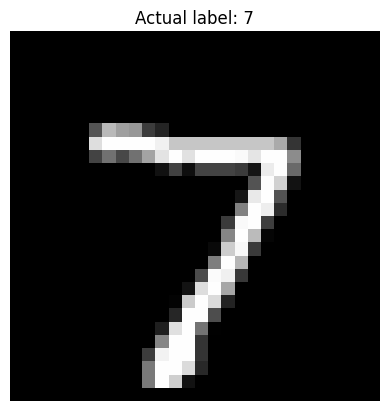

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Training data:", len(train_dataset))
print("Testing data:", len(test_dataset))

image, label = test_dataset[0]

print("Image shape:", image.shape)
print("Actual label:", label)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual label: {label}")
plt.axis("off")
plt.show()

## Langkah 3 — Bina model ANN

In [5]:
ann_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

print(ann_model)

ann_criterion = nn.CrossEntropyLoss()
ann_optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001
)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


## Langkah 4 — Latih dan uji ANN

In [6]:
ann_epochs = 2
for epoch in range(ann_epochs):
    ann_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        ann_optimizer.zero_grad()
        outputs = ann_model(images)
        loss = ann_criterion(outputs, labels)
        loss.backward()
        ann_optimizer.step()
        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    print(
        f"Epoch {epoch + 1}/{ann_epochs} - "
        f"Loss: {average_loss:.4f}"
    )

ann_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = ann_model(images)
        predictions = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

ann_accuracy = 100 * correct / total
print(f"ANN Testing Accuracy: {ann_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.3328
Epoch 2/2 - Loss: 0.1354
ANN Testing Accuracy: 96.43%


## Langkah 5 — Bina model CNN

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 -> 14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 14 * 14, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = CNN().to(device)
print(cnn_model)

# Semak saiz tensor
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)
print("Input batch:", list(sample_batch.shape))
after_pool = cnn_model.features(sample_batch)
print("Selepas pooling:", list(after_pool.shape))
out = cnn_model(sample_batch)
print("Output model:", list(out.shape))

cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
Input batch: [64, 1, 28, 28]
Selepas pooling: [64, 16, 14, 14]
Output model: [64, 10]


## Langkah 6 — Latih dan uji CNN

In [8]:
cnn_epochs = 2
for epoch in range(cnn_epochs):
    cnn_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        cnn_optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = cnn_criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    print(
        f"Epoch {epoch + 1}/{cnn_epochs} - "
        f"Loss: {average_loss:.4f}"
    )
    cnn_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn_model(images)
        predictions = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

cnn_accuracy = 100 * correct / total
print(f"CNN Testing Accuracy: {cnn_accuracy:.2f}%")

Epoch 1/2 - Loss: 0.3326
Epoch 2/2 - Loss: 0.1098
CNN Testing Accuracy: 97.15%


## Langkah 7 — Uji lima imej digit

Image 1: Actual: 7, ANN: 7 [BETUL], CNN: 7 [BETUL]
Image 2: Actual: 2, ANN: 2 [BETUL], CNN: 2 [BETUL]
Image 3: Actual: 1, ANN: 1 [BETUL], CNN: 1 [BETUL]
Image 4: Actual: 0, ANN: 0 [BETUL], CNN: 0 [BETUL]
Image 5: Actual: 4, ANN: 4 [BETUL], CNN: 4 [BETUL]


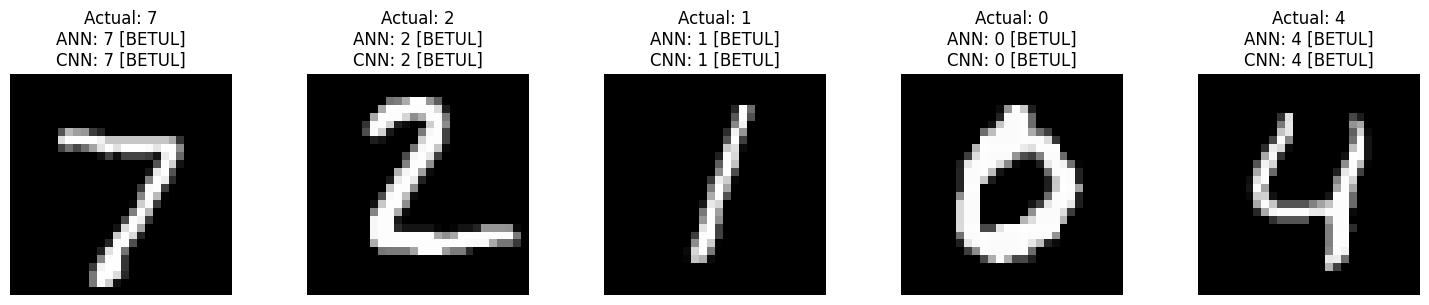

ANN ramalan betul: 5/5
CNN ramalan betul: 5/5


In [9]:
ann_model.eval()
cnn_model.eval()
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
ann_correct_count = 0
cnn_correct_count = 0

for i in range(num_images):
    image, actual_label = test_dataset[i]
    image_batch = image.unsqueeze(0).to(device)
    with torch.no_grad():
        ann_output = ann_model(image_batch)
        cnn_output = cnn_model(image_batch)

    ann_prediction = torch.argmax(ann_output, dim=1).item()
    cnn_prediction = torch.argmax(cnn_output, dim=1).item()
    ann_status = "BETUL" if ann_prediction == actual_label else "SALAH"
    cnn_status = "BETUL" if cnn_prediction == actual_label else "SALAH"

    if ann_prediction == actual_label:
        ann_correct_count += 1
    if cnn_prediction == actual_label:
        cnn_correct_count += 1

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(
        f"Actual: {actual_label}\n"
        f"ANN: {ann_prediction} [{ann_status}]\n"
        f"CNN: {cnn_prediction} [{cnn_status}]"
    )
    axes[i].axis("off")

    print(
        f"Image {i + 1}: "
        f"Actual: {actual_label}, "
        f"ANN: {ann_prediction} [{ann_status}], "
        f"CNN: {cnn_prediction} [{cnn_status}]"
    )

plt.tight_layout()
plt.show()

print(f"ANN ramalan betul: {ann_correct_count}/5")
print(f"CNN ramalan betul: {cnn_correct_count}/5")

## Langkah 8 — Bandingkan ANN dan CNN

  MODEL  EPOCH TESTING ACCURACY  RAMALAN BETUL / 5
0   ANN      2           96.43%                  5
1   CNN      2           97.15%                  5


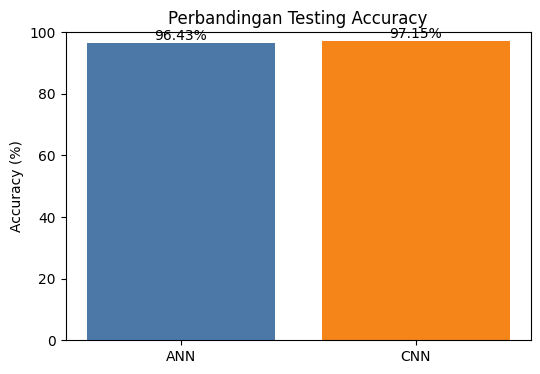


RUMUSAN AKHIR
Model dengan accuracy lebih tinggi: CNN
Model dengan ramalan betul lebih banyak: Sama


In [12]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

def calculate_accuracy(model, data_loader, flatten_input=False):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            if flatten_input:
                images = images.view(images.size(0), -1)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def count_correct_five(model, data_loader, flatten_input=False):
    model.eval()
    with torch.no_grad():
        images, labels = next(iter(data_loader))
        images, labels = images[:5], labels[:5]
        if flatten_input:
            x = images.view(images.size(0), -1)
        else:
            x = images
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        return (predicted == labels).sum().item()

ann_accuracy = calculate_accuracy(ann_model, test_loader, flatten_input=True)
cnn_accuracy = calculate_accuracy(cnn_model, test_loader, flatten_input=False)
ann_correct5 = count_correct_five(ann_model, test_loader, flatten_input=True)
cnn_correct5 = count_correct_five(cnn_model, test_loader, flatten_input=False)

table = pd.DataFrame({
    "MODEL": ["ANN", "CNN"],
    "EPOCH": [2, 2],
    "TESTING ACCURACY": [f"{ann_accuracy:.2f}%", f"{cnn_accuracy:.2f}%"],
    "RAMALAN BETUL / 5": [ann_correct5, cnn_correct5]
})

print(table)

plt.figure(figsize=(6, 4))
bars = plt.bar(["ANN", "CNN"], [ann_accuracy, cnn_accuracy], color=["#4C78A8", "#F58518"])
plt.title("Perbandingan Testing Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, acc in zip(bars, [ann_accuracy, cnn_accuracy]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{acc:.2f}%", ha="center")

plt.show()

acc_winner = "CNN" if cnn_accuracy > ann_accuracy else "ANN" if ann_accuracy > cnn_accuracy else "Sama"
pred_winner = "CNN" if cnn_correct5 > ann_correct5 else "ANN" if ann_correct5 > cnn_correct5 else "Sama"

print("\nRUMUSAN AKHIR")
print(f"Model dengan accuracy lebih tinggi: {acc_winner}")
print(f"Model dengan ramalan betul lebih banyak: {pred_winner}")

## Langkah 9 — Rekod penggunaan AI Code Assistant

**Nama AI Code Assistant:** ChatGPT

**Satu masalah/prompt:** “Mengapa saiz input bagi layer Linear CNN ialah 16 × 14 × 14?”

**Ringkasan cadangan:** Selepas Conv2d, imej masih bersaiz 28 × 28. MaxPool2d dengan kernel 2 mengurangkan saiz kepada 14 × 14. Oleh itu, output convolution layer ialah 16 × 14 × 14.

**Tindakan selepas menyemak cadangan:** Saya menyemak bentuk tensor menggunakan `print(after_pooling.shape)` dan menggunakan nilai `16 * 14 * 14` pada fully connected layer.